# Chapter 8f — Who Emits, Emissions Intensity, and Multi-Gas Accounting

This notebook covers 8 scripts: `chap8_anthropogenic4a`-`4e`,
`chap8_anthropogenic5a`-`5b`, and `chap8_anthropogenic6`. It continues
`08e`'s data-driven look at the observational and accounting side of
anthropogenic warming — this time asking *who* is responsible for
emissions (by region and by country, both annually and cumulatively),
*how efficiently* the world converts energy and GDP into emissions, and
what the full multi-gas (not just CO$_2$) picture looks like once methane
and nitrous oxide are converted to CO$_2$-equivalent using their 100-year
global warming potentials (GWP-100).

`chap8_anthropogenic4a` computes a "World" aggregate as an internal
consistency check with no figure of its own in the source script — folded
into section 1 below rather than given its own section.

**Real data used:** Our World in Data / Global Carbon Budget regional and
national CO$_2$-share panels (`ghg2`, `ghg3`), World Bank-derived carbon-
and-energy-intensity series (`ghg4`), and PRIMAP-hist-style multi-gas
emissions by gas and component (`ghg5`) — all shipped as `.xlsx` in
`hfs-archive`'s own `Data/` folder.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

DATA_DIR = "../../data"

color_blue    = np.array([  0,  20, 255]) / 255
color_red     = np.array([255,  80,  50]) / 255
color_green   = np.array([ 20, 200,  80]) / 255
color_violet  = np.array([255,  51, 255]) / 255
color_teal    = np.array([ 56, 142, 142]) / 255
color_matlab  = np.array([0, 0.4470, 0.7410])
color_pink    = np.array([255, 105, 180]) / 255

def region_panel(xlsx_name, regions, share_col):
    df = pd.read_excel(f"{DATA_DIR}/{xlsx_name}")
    all_years = np.sort(df["year"].unique())
    data = pd.DataFrame(0.0, index=all_years, columns=regions)
    for r in regions:
        sub = df[df["country"] == r].set_index("year")[share_col]
        data.loc[sub.index, r] = sub.values
    data = data.replace(0.0, np.nan).ffill().fillna(0.0)
    return data


## 1. Regional shares of global CO$_2$ emissions (`chap8_anthropogenic4a`-`4c`)

Stacked-area view of each world region's share of annual, and then
cumulative, global CO$_2$ emissions since 1750. `4a`'s "World" column is
just the sum of the seven regions, used here only as a consistency check
(it should sum to ~100% at every year, confirmed below) rather than a
figure in its own right.


Cumulative-share consistency check: min=99.99%, max=100.00% (should be close to 100% throughout)


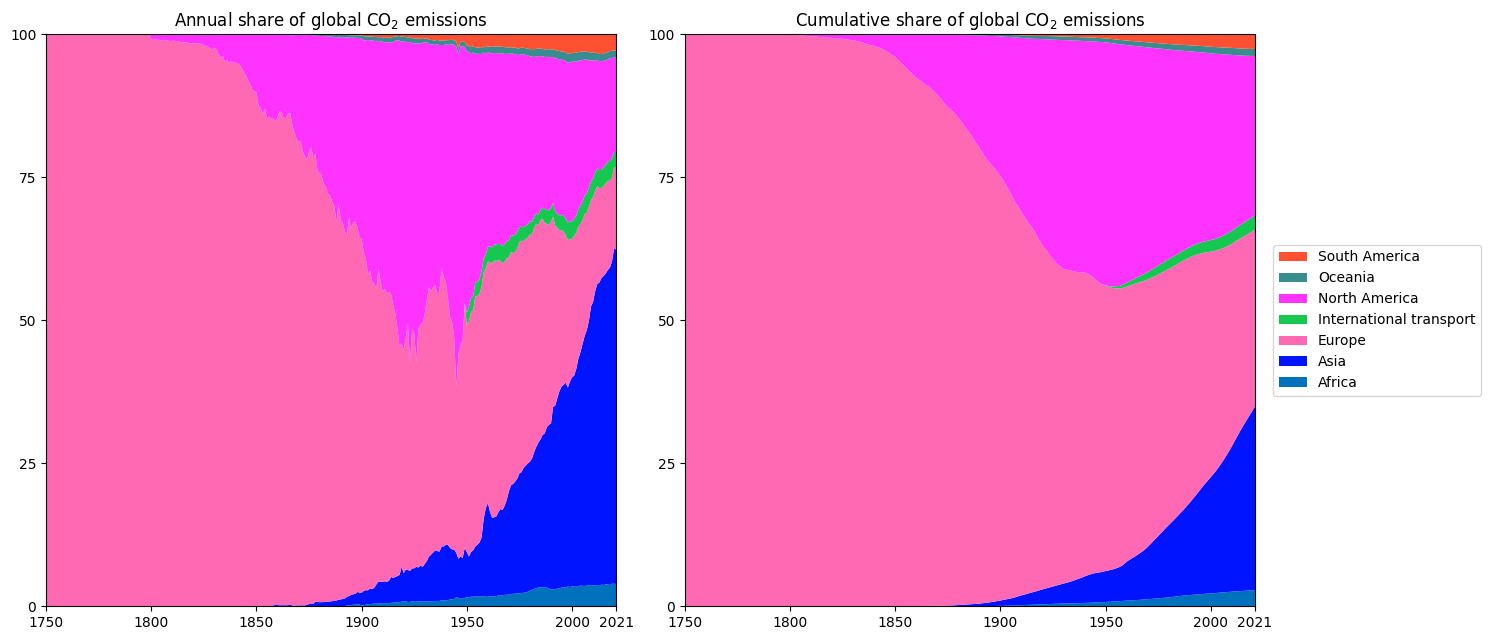

In [2]:

regions = ["Africa", "Asia", "Europe", "International transport",
           "North America", "Oceania", "South America"]

annual_share = region_panel("chap8_anthropogenic_ghg2.xlsx", regions, "share_global_co2")
cumulative_share = region_panel("chap8_anthropogenic_ghg2.xlsx", regions, "share_global_cumulative_co2")

world_check = cumulative_share.sum(axis=1)
print(f"Cumulative-share consistency check: min={world_check.min():.2f}%, max={world_check.max():.2f}% "
      f"(should be close to 100% throughout)")

colors7 = [color_matlab, color_blue, color_pink, color_green, color_violet, color_teal, color_red]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, data, title in zip(axes, [annual_share, cumulative_share],
                            ["Annual share of global CO$_2$ emissions", "Cumulative share of global CO$_2$ emissions"]):
    ax.stackplot(data.index, [data[r] for r in regions], labels=regions, colors=colors7)
    ax.set_xlim(1750, 2021); ax.set_xticks([1750, 1800, 1850, 1900, 1950, 2000, 2021])
    ax.set_ylim(0, 100); ax.set_yticks(np.arange(0, 101, 25))
    ax.set_title(title, fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles[::-1], labels[::-1], loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=10)
plt.tight_layout()
plt.show()


## 2. National shares of global CO$_2$ emissions (`chap8_anthropogenic4d`-`4e`)

Same idea at the country level, for the 19 largest historical emitters
tracked in the source (`ghg3`), again annual and cumulative.


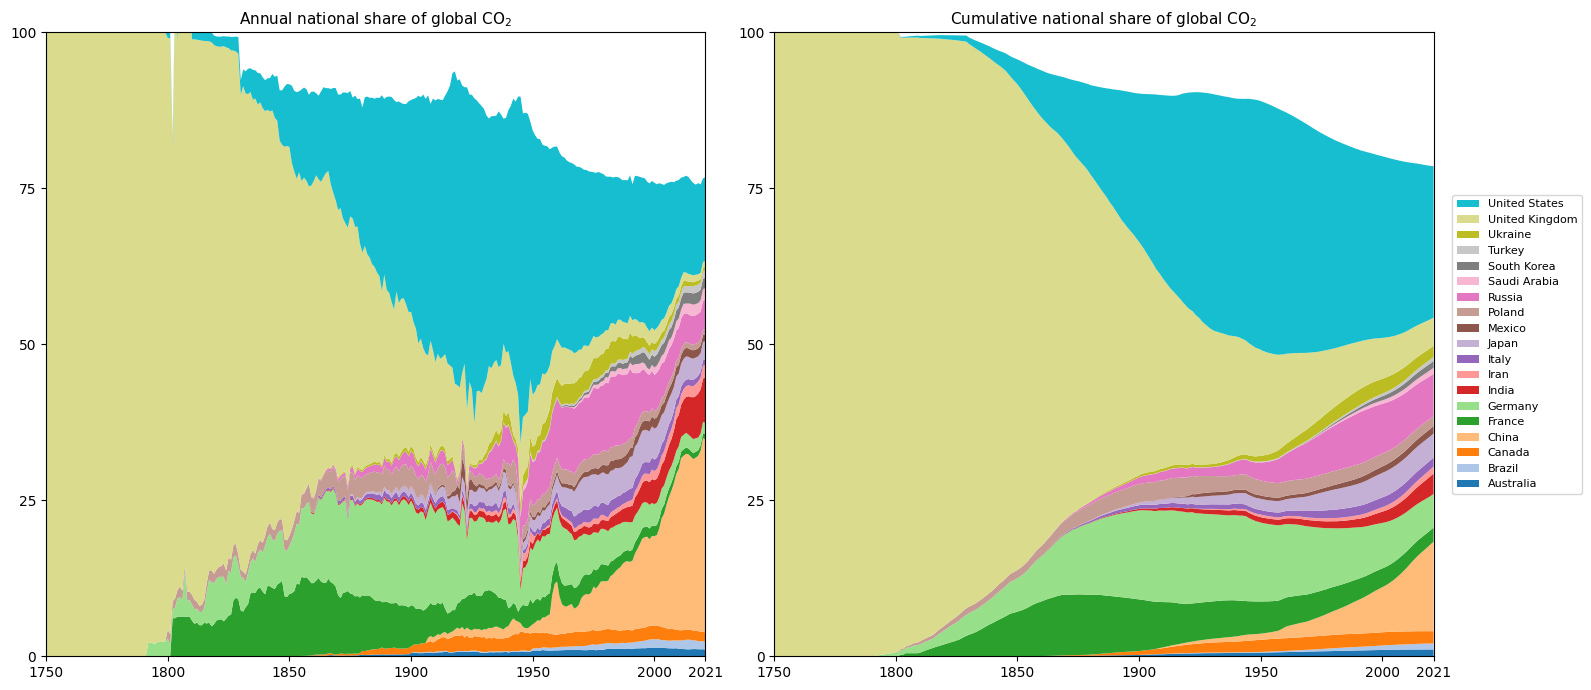

2021 cumulative share of global CO2, ranked (%):


,cumulative share (%)
United States,24.29
China,14.36
Russia,6.77
Germany,5.37
United Kingdom,4.52
Japan,3.84
India,3.29
France,2.25
Canada,1.96
Ukraine,1.77


In [3]:

countries19 = ["Australia", "Brazil", "Canada", "China", "France", "Germany", "India", "Iran",
               "Italy", "Japan", "Mexico", "Poland", "Russia", "Saudi Arabia", "South Korea",
               "Turkey", "Ukraine", "United Kingdom", "United States"]

annual_share_c = region_panel("chap8_anthropogenic_ghg3.xlsx", countries19, "share_global_co2")
cumulative_share_c = region_panel("chap8_anthropogenic_ghg3.xlsx", countries19, "share_global_cumulative_co2")

colors19 = plt.get_cmap("tab20").colors[:len(countries19)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, data, title in zip(axes, [annual_share_c, cumulative_share_c],
                            ["Annual national share of global CO$_2$", "Cumulative national share of global CO$_2$"]):
    ax.stackplot(data.index, [data[c] for c in countries19], labels=countries19, colors=colors19)
    ax.set_xlim(1750, 2021); ax.set_xticks([1750, 1800, 1850, 1900, 1950, 2000, 2021])
    ax.set_ylim(0, 100); ax.set_yticks(np.arange(0, 101, 25))
    ax.set_title(title, fontsize=11)

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles[::-1], labels[::-1], loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

ranking = cumulative_share_c.iloc[-1].sort_values(ascending=False)
print("2021 cumulative share of global CO2, ranked (%):")
display(ranking.round(2).to_frame("cumulative share (%)"))


## 3. Carbon and energy intensity (`chap8_anthropogenic5a`-`5b`)

Four intensity metrics that decompose *why* global emissions have grown
(or not): how much CO$_2$ each unit of energy produces, how much energy
each unit of GDP requires, the product of the two (CO$_2$ per GDP), and
GDP per capita. Each series has gaps in the source data at different
years, so — matching the source script exactly — each is independently
stripped of its own missing values and cubic-spline-interpolated onto a
common annual grid, rather than the four columns being aligned first and
interpolated together.


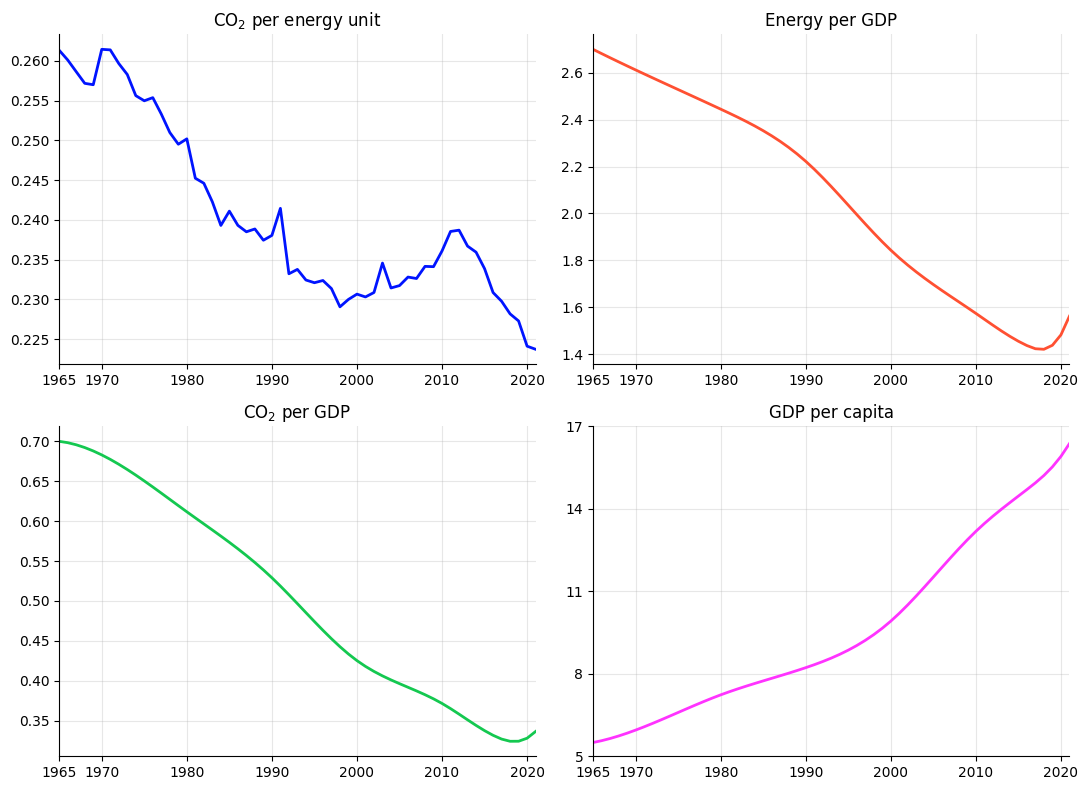

In [4]:

ghg4 = pd.read_excel(f"{DATA_DIR}/chap8_anthropogenic_ghg4.xlsx")
ghg4 = ghg4[ghg4["country"] == "World"].sort_values("year")
ghg4 = ghg4[ghg4["year"] >= 1965]

series_info = [
    ("co2_per_unit_energy", "CO$_2$ per energy unit", color_blue, False),
    ("energy_per_gdp", "Energy per GDP", color_red, False),
    ("co2_per_gdp", "CO$_2$ per GDP", color_green, False),
    ("gdp_per_capita", "GDP per capita", color_violet, True),
]

t = np.arange(1965, 2022)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (col, title, c, scale_1000) in zip(axes.flat, series_info):
    sub = ghg4[["year", col]].dropna()
    cs = CubicSpline(sub["year"].to_numpy(), sub[col].to_numpy())
    z = cs(t)
    if scale_1000:
        z = z / 1000
    ax.plot(t, z, "-", color=c, linewidth=2.0)
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=12)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_xlim(1965, 2021); ax.set_xticks([1965, 1970, 1980, 1990, 2000, 2010, 2020])
    if title == "GDP per capita":
        ax.set_ylim(5, 17); ax.set_yticks(np.arange(5, 18, 3))

plt.tight_layout()
plt.show()


### Per-capita CO$_2$ emissions (`chap8_anthropogenic5b`)

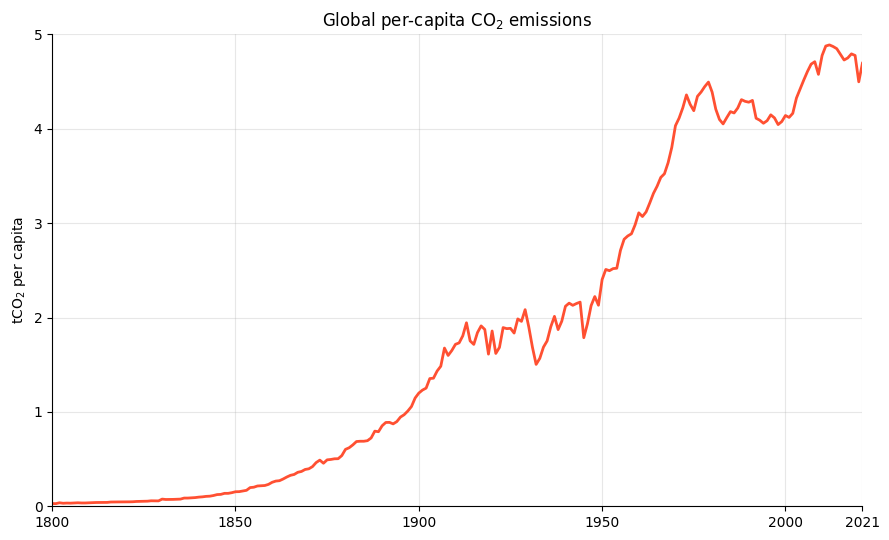

In [5]:

ghg4_full = pd.read_excel(f"{DATA_DIR}/chap8_anthropogenic_ghg4.xlsx")
ghg4_full = ghg4_full[ghg4_full["country"] == "World"].sort_values("year")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(ghg4_full["year"], ghg4_full["co2_per_capita"], "-", color=color_red, linewidth=2.0)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_xlim(1800, 2021); ax.set_xticks(list(range(1800, 2021, 50)) + [2021])
ax.set_ylim(0, 5); ax.set_yticks(range(0, 6))
ax.set_ylabel("tCO$_2$ per capita")
ax.set_title("Global per-capita CO$_2$ emissions")
plt.tight_layout()
plt.show()


## 4. Multi-gas, GWP-weighted emissions (`chap8_anthropogenic6`)

CO$_2$ is only part of the anthropogenic warming story. This section adds
methane (CH$_4$) and nitrous oxide (N$_2$O), converting both to
CO$_2$-equivalent using their AR6 100-year global warming potentials
(GWP-100 = 27.9 for CH$_4$, 273 for N$_2$O — fossil-source CH$_4$ value;
the source uses a single GWP per gas without distinguishing fossil vs.
biogenic methane, reproduced as-is here).


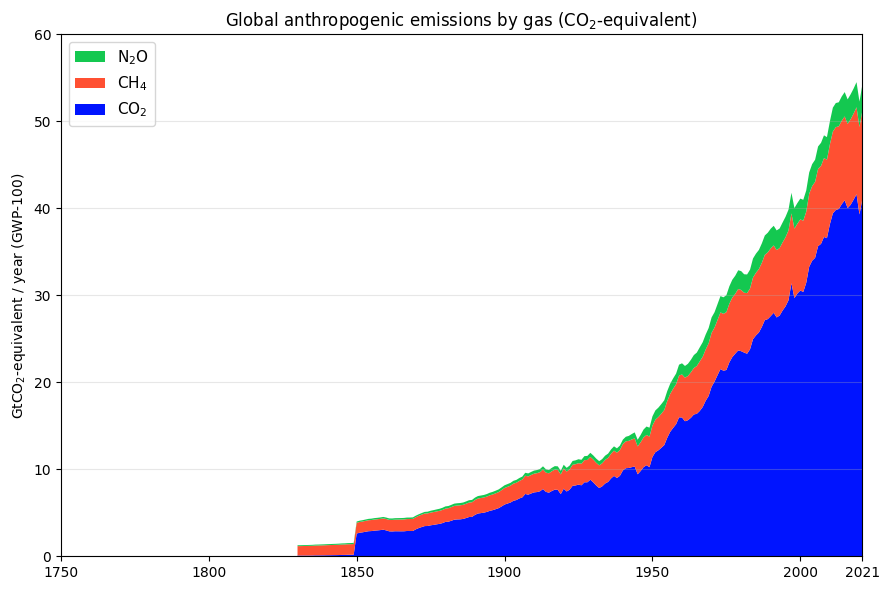

In [6]:

ghg5 = pd.read_excel(f"{DATA_DIR}/chap8_anthropogenic_ghg5.xlsx")
ghg5 = ghg5[ghg5["Region"] == "GLOBAL"]

gases = ["CO[2]", "CH[4]", "N[2]*O"]
gas_labels = ["CO$_2$", "CH$_4$", "N$_2$O"]
to_pg = {"CO[2]": 1.0, "CH[4]": 1e-3, "N[2]*O": 1e-3}   # Pg already for CO2; Tg -> Pg for CH4/N2O
gwp = {"CO[2]": 1.0, "CH[4]": 27.9, "N[2]*O": 273.0}

total = ghg5[ghg5["Component"] == "Total"]
all_years = np.sort(total["Year"].unique())
data = pd.DataFrame(index=all_years, columns=gas_labels, dtype=float)
for g, lbl in zip(gases, gas_labels):
    sub = total[total["Gas"] == g].set_index("Year")["Data"]
    data[lbl] = (sub.reindex(all_years) * to_pg[g] * gwp[g]).values

colors3 = [color_blue, color_red, color_green]
fig, ax = plt.subplots(figsize=(9, 6))
ax.stackplot(data.index, [data[c] for c in gas_labels], labels=gas_labels, colors=colors3)
ax.set_xlim(1850, 2021); ax.set_xticks([1750, 1800, 1850, 1900, 1950, 2000, 2021])
ax.set_ylim(0, 60); ax.set_yticks(range(0, 61, 10))
ax.grid(True, axis="y", alpha=0.3)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc="upper left", fontsize=11)
ax.set_ylabel("GtCO$_2$-equivalent / year (GWP-100)")
ax.set_title("Global anthropogenic emissions by gas (CO$_2$-equivalent)")
plt.tight_layout()
plt.show()


In [7]:

components = ["Fossil", "LULUCF", "Total"]
year2021 = ghg5[ghg5["Year"] == 2021]

table = pd.DataFrame(index=gas_labels, columns=components, dtype=float)
for g, lbl in zip(gases, gas_labels):
    for comp in components:
        row = year2021[(year2021["Gas"] == g) & (year2021["Component"] == comp)]
        val = row["Data"].iloc[0] if len(row) else np.nan
        table.loc[lbl, comp] = val * to_pg[g] * gwp[g]

print("2021 emissions by gas and component (GtCO2-equivalent, GWP-100):")
display(table.round(2))

share_of_total = 100 * table.div(table["Total"], axis=0)
print("\nShare of each gas's own total (%):")
display(share_of_total.round(2))

gas_share_of_grand_total = 100 * table["Total"] / table["Total"].sum()
print("\nEach gas's share of the 2021 grand total (%):")
display(gas_share_of_grand_total.round(2).to_frame("share (%)"))


2021 emissions by gas and component (GtCO2-equivalent, GWP-100):


,Fossil,LULUCF,Total
CO$_2$,37.11,4.00,41.12
CH$_4$,6.23,3.95,10.18
N$_2$O,0.79,2.18,2.97



Share of each gas's own total (%):


,Fossil,LULUCF,Total
CO$_2$,90.26,9.74,100.0
CH$_4$,61.22,38.78,100.0
N$_2$O,26.69,73.31,100.0



Each gas's share of the 2021 grand total (%):


,share (%)
CO$_2$,75.77
CH$_4$,18.76
N$_2$O,5.47


## Summary

This notebook closes out the "who and how" side of anthropogenic
emissions accounting: regional and national shares (both annual and
cumulative — cumulative shares matter more for warming since CO$_2$
accumulates in the atmosphere for centuries), carbon/energy intensity
trends showing the world has gotten steadily *more* efficient per unit of
GDP even as total emissions rose, and the full multi-gas picture once
methane and nitrous oxide are put on a common CO$_2$-equivalent basis
(CO$_2$ dominates, but CH$_4$ and N$_2$O together are a non-trivial share
of total forcing-relevant emissions).

**Note on `colors19`:** the source MATLAB script hand-specifies 14 named
colors (e.g. `color_yellow`, `color_maroon`) from the `hfs-archive` style
file for the 19-country stacked-area charts. Since precise color identity
doesn't affect the chart's correctness — only that the 19 series are
visually distinguishable — this notebook uses matplotlib's `tab20`
qualitative colormap instead of hand-porting 14 individual RGB triples.

No new packaging candidates from this notebook — `region_panel` is a
convenience wrapper tied to the specific `ghg2`/`ghg3` column layout, not
a generic primitive.
